<a href="https://colab.research.google.com/github/mandasneha2006-blip/EEG-processing1/blob/main/Tiny_EEG_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from PIL import Image, ImageFilter, ImageEnhance
from io import BytesIO

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2: Upload Parrot Images

from google.colab import files

uploaded = files.upload()

print("Number of images uploaded:", len(uploaded))

Saving Green parrot (1).webp to Green parrot (1) (1).webp
Saving Green parrot (2).jpg to Green parrot (2) (1).jpg
Saving Green parrot (3).jpg to Green parrot (3) (1).jpg
Saving Green parrot (4).jpg to Green parrot (4) (1).jpg
Saving Green parrot (5).jpg to Green parrot (5) (1).jpg
Saving Green parrot (6).jpg to Green parrot (6) (1).jpg
Saving Green parrot (7).jpg to Green parrot (7) (1).jpg
Saving Green parrot (8).jpg to Green parrot (8) (1).jpg
Saving Green parrot (9).jpg to Green parrot (9) (1).jpg
Saving Green parrot (10).jpg to Green parrot (10) (1).jpg
Saving Green parrot (11).jpg to Green parrot (11) (1).jpg
Saving Green parrot (12).jpg to Green parrot (12) (1).jpg
Saving Green parrot (13).jpg to Green parrot (13) (1).jpg
Saving Green parrot (14).jpg to Green parrot (14) (1).jpg
Saving Green parrot (15).jpg to Green parrot (15) (1).jpg
Number of images uploaded: 15


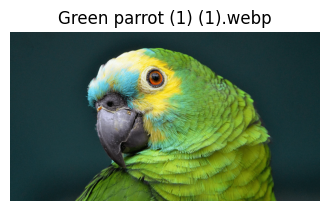

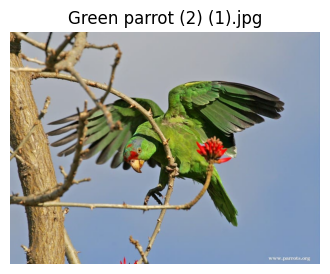

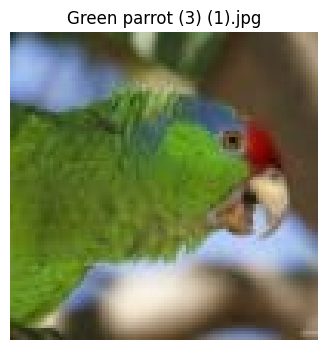

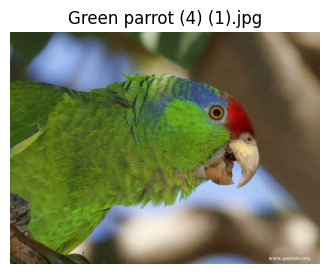

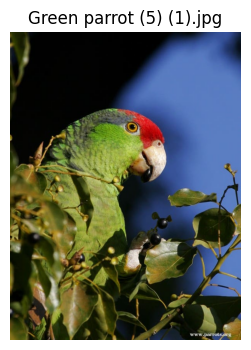

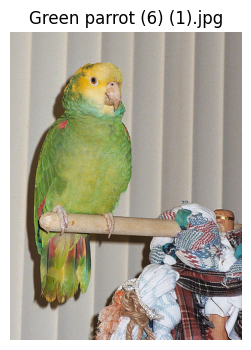

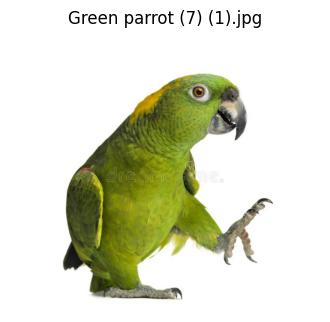

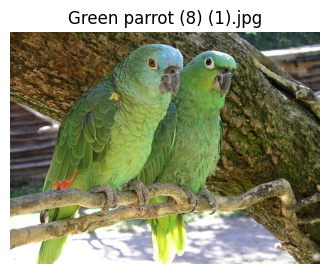

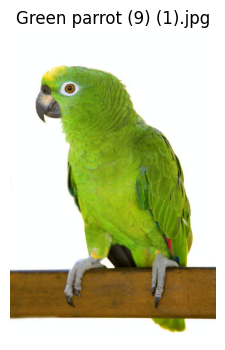

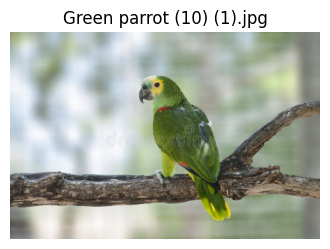

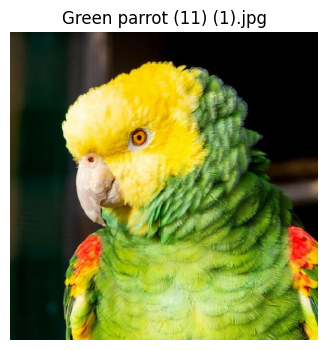

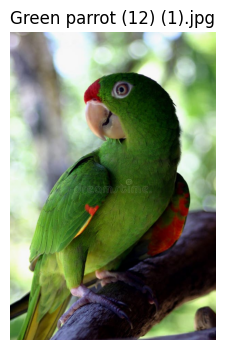

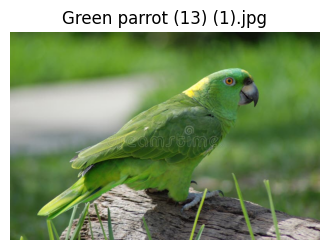

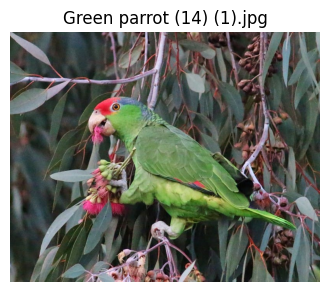

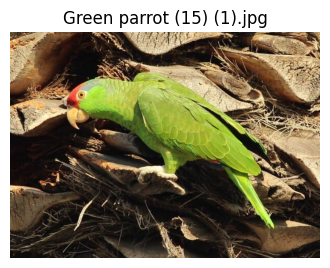

In [ ]:
# Cell 3: Display Uploaded Parrot Images

for filename, data in uploaded.items():

    img = Image.open(BytesIO(data))

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(filename)
    plt.axis("off")
    plt.show()

In [ ]:
# Cell 4: Create Output Folder

output_folder = "parrot_output"

os.makedirs(output_folder, exist_ok=True)

print("Output folder created successfully!")

Output folder created successfully!


First image: Green parrot (1) (1).webp
Image size: (1920, 1048)
Image mode: RGB


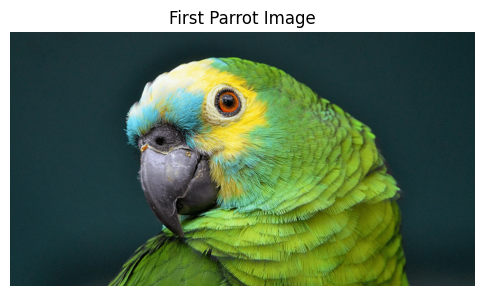

In [ ]:
# Cell 5: Read First Parrot Image

first_filename = list(uploaded.keys())[0]

first_image = Image.open(
    BytesIO(uploaded[first_filename])
).convert("RGB")

print("First image:", first_filename)
print("Image size:", first_image.size)
print("Image mode:", first_image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(first_image)
plt.title("First Parrot Image")
plt.axis("off")
plt.show()

Original size: (1920, 1048)
Resized size: (224, 224)


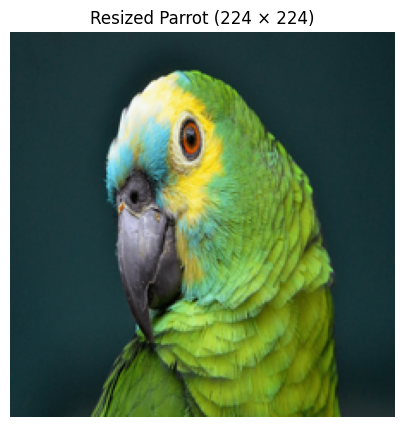

In [ ]:
# Cell 6: Resize Image

resize_size = (224, 224)

resized_image = first_image.resize(resize_size)

print("Original size:", first_image.size)
print("Resized size:", resized_image.size)

plt.figure(figsize=(5, 5))
plt.imshow(resized_image)
plt.title("Resized Parrot (224 × 224)")
plt.axis("off")
plt.show()

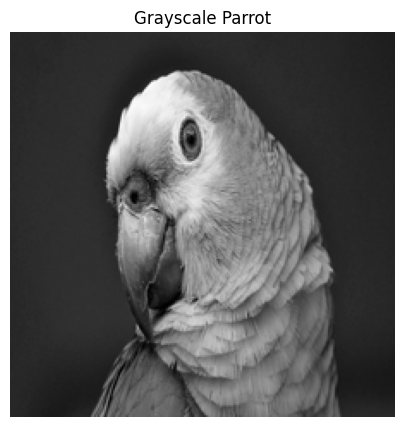

In [ ]:
# Cell 7: Convert to Grayscale

gray_image = resized_image.convert("L")

plt.figure(figsize=(5, 5))
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Parrot")
plt.axis("off")
plt.show()

Noise removal completed.


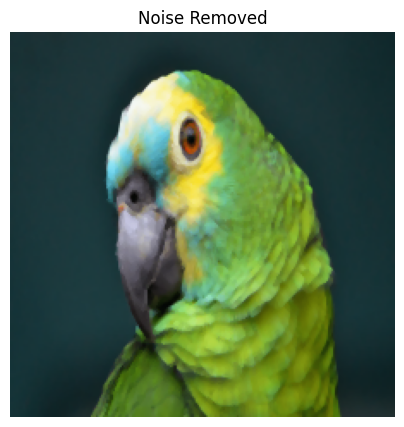

In [ ]:
# Cell 8: Noise Removal

denoised_image = resized_image.filter(
    ImageFilter.MedianFilter(size=3)
)

print("Noise removal completed.")

plt.figure(figsize=(5, 5))
plt.imshow(denoised_image)
plt.title("Noise Removed")
plt.axis("off")
plt.show()

Contrast enhancement completed.


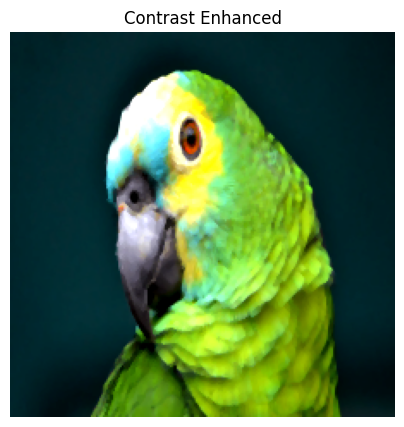

In [ ]:
# Cell 9: Contrast Enhancement

enhancer = ImageEnhance.Contrast(denoised_image)

contrast_image = enhancer.enhance(1.5)

print("Contrast enhancement completed.")

plt.figure(figsize=(5, 5))
plt.imshow(contrast_image)
plt.title("Contrast Enhanced")
plt.axis("off")
plt.show()

Normalization completed.
Minimum: 0.0
Maximum: 1.0
Shape: (224, 224, 3)


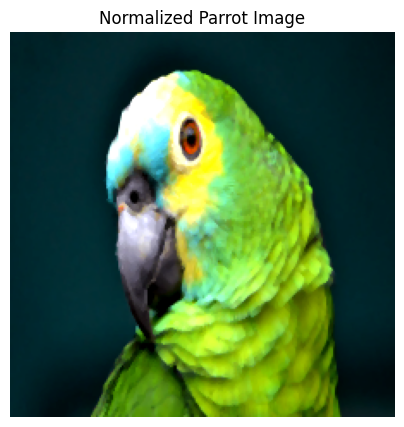

In [ ]:
# Cell 10: Normalization

normalized_image = np.array(
    contrast_image,
    dtype=np.float32
) / 255.0

print("Normalization completed.")
print("Minimum:", normalized_image.min())
print("Maximum:", normalized_image.max())
print("Shape:", normalized_image.shape)

plt.figure(figsize=(5, 5))
plt.imshow(normalized_image)
plt.title("Normalized Parrot Image")
plt.axis("off")
plt.show()

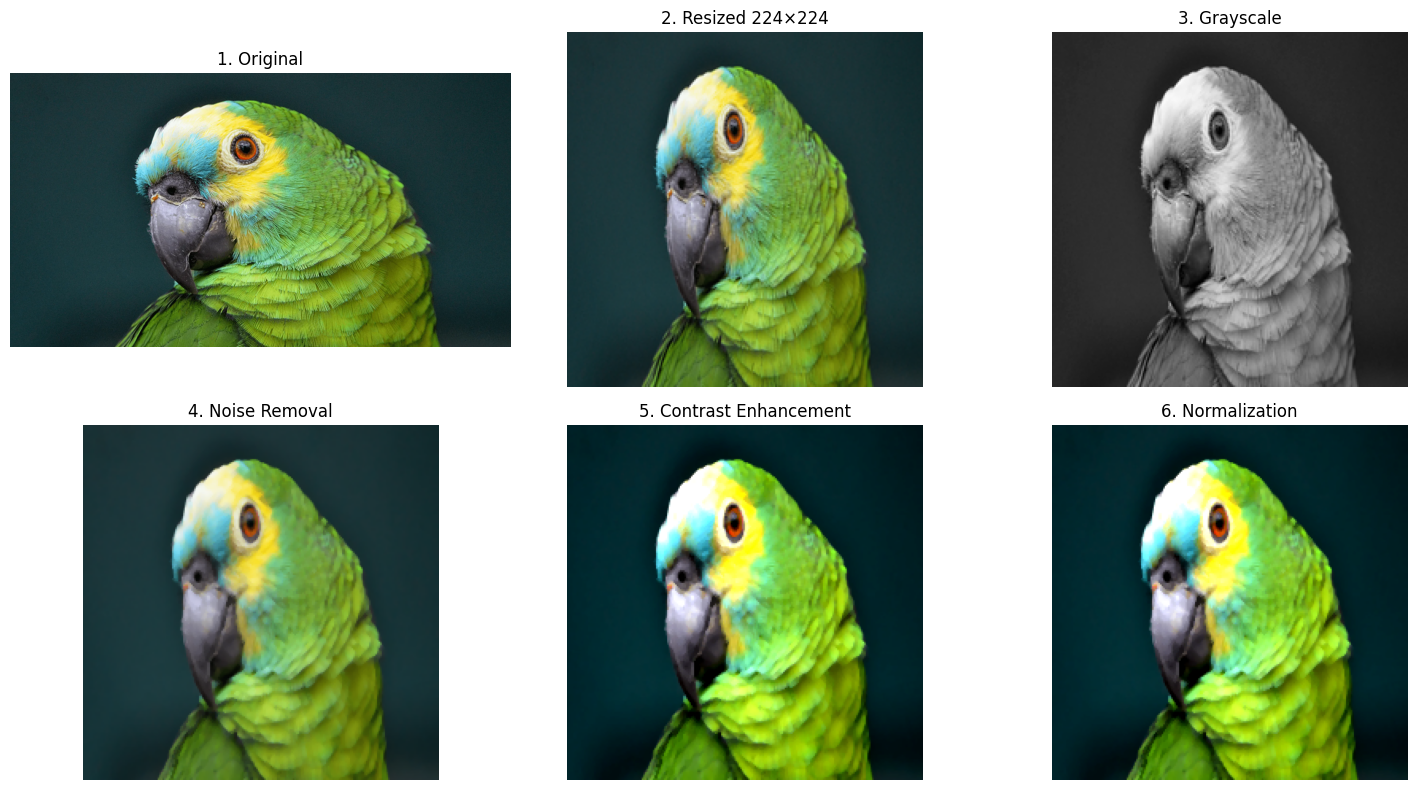

In [ ]:
# Cell 11: Visualize All Preprocessing Stages

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(first_image)
plt.title("1. Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(resized_image)
plt.title("2. Resized 224×224")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gray_image, cmap="gray")
plt.title("3. Grayscale")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(denoised_image)
plt.title("4. Noise Removal")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(contrast_image)
plt.title("5. Contrast Enhancement")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(normalized_image)
plt.title("6. Normalization")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 12: Process All Parrot Images

for filename, data in uploaded.items():

    # Read image
    image = Image.open(BytesIO(data)).convert("RGB")

    # Resize
    image = image.resize((224, 224))

    # Noise removal
    image = image.filter(
        ImageFilter.MedianFilter(size=3)
    )

    # Contrast enhancement
    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(1.5)

    # Save processed image
    output_path = os.path.join(
        output_folder,
        filename
    )

    image.save(output_path)

print("All parrot images processed successfully!")

All parrot images processed successfully!


In [ ]:
# Cell 13: Check Saved Images

saved_images = os.listdir(output_folder)

print("Processed images saved:", len(saved_images))

for filename in saved_images:
    print(filename)

Processed images saved: 15
Green parrot (9) (1).jpg
Green parrot (10) (1).jpg
Green parrot (3) (1).jpg
Green parrot (4) (1).jpg
Green parrot (11) (1).jpg
Green parrot (1) (1).webp
Green parrot (7) (1).jpg
Green parrot (15) (1).jpg
Green parrot (6) (1).jpg
Green parrot (2) (1).jpg
Green parrot (13) (1).jpg
Green parrot (8) (1).jpg
Green parrot (12) (1).jpg
Green parrot (14) (1).jpg
Green parrot (5) (1).jpg


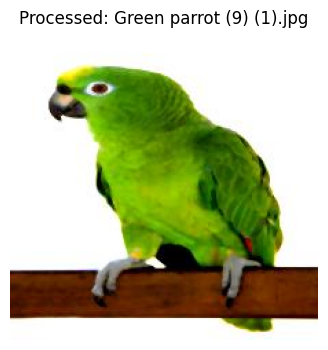

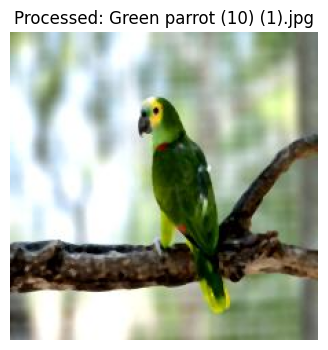

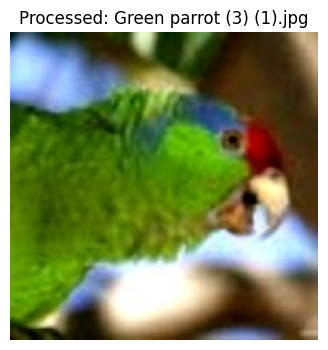

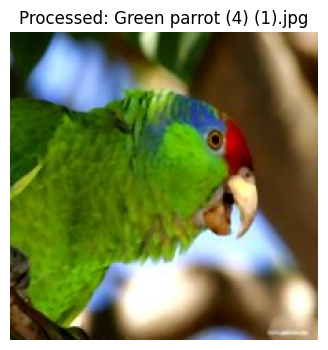

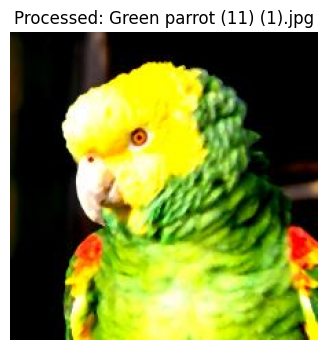

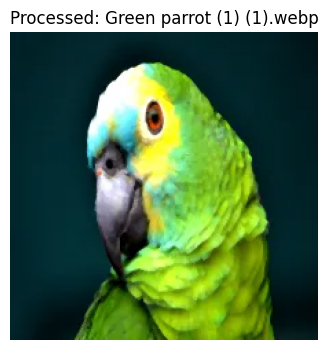

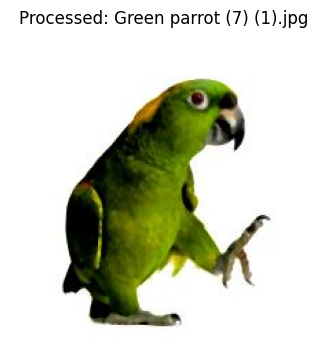

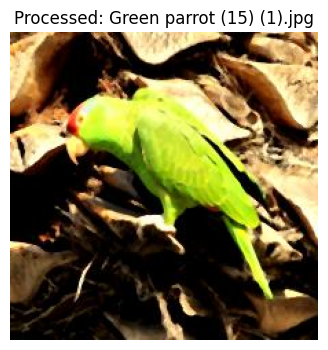

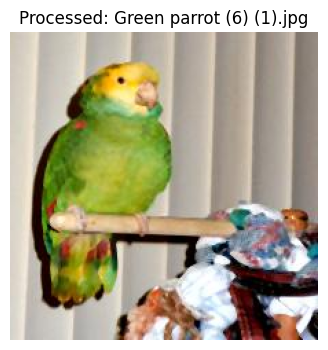

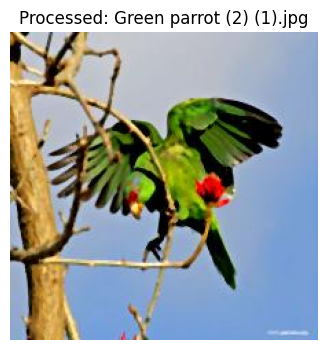

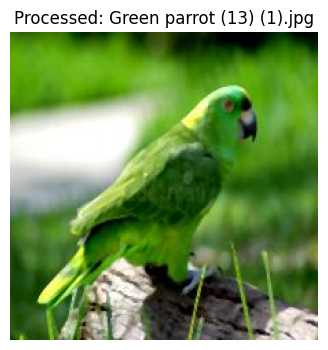

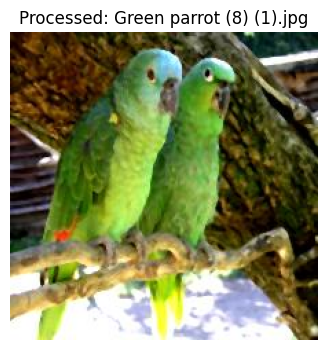

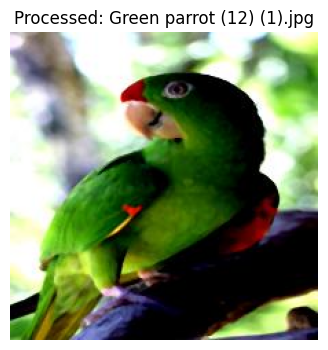

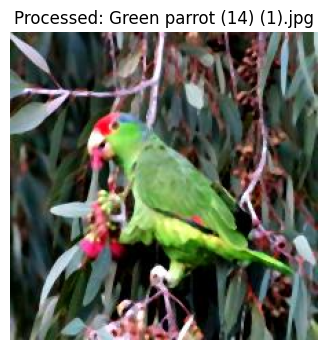

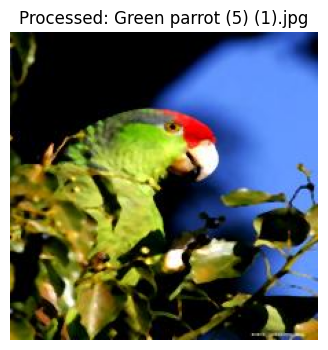

In [ ]:
# Cell 14: Display Processed Images

for filename in saved_images:

    path = os.path.join(output_folder, filename)
    img = Image.open(path)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title("Processed: " + filename)
    plt.axis("off")
    plt.show()

In [ ]:
# Cell 15: Check Image Mode

sample_path = os.path.join(
    output_folder,
    saved_images[0]
)

sample_image = Image.open(sample_path)

print("Image mode:", sample_image.mode)
print("Image size:", sample_image.size)

Image mode: RGB
Image size: (224, 224)


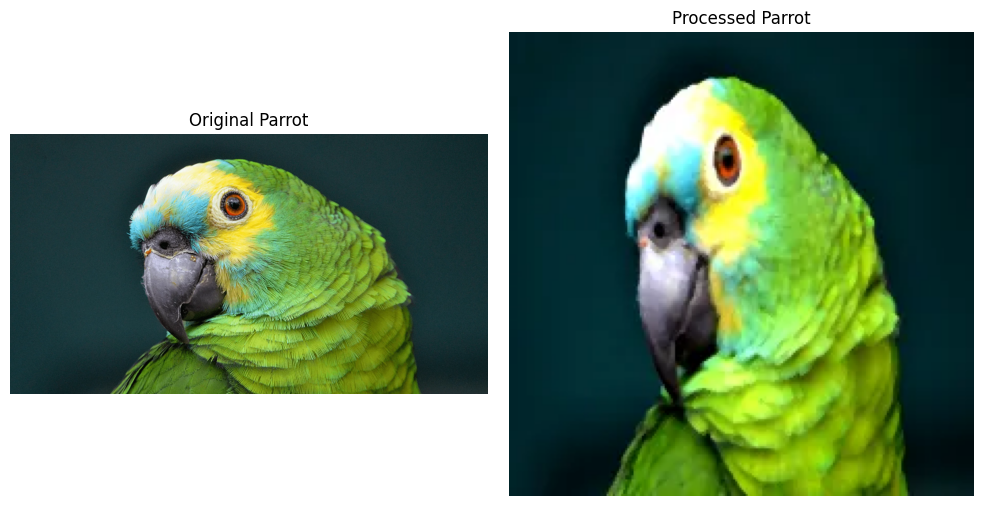

In [ ]:
# Cell 16: Original vs Processed

processed_image = Image.open(
    os.path.join(output_folder, first_filename)
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(first_image)
plt.title("Original Parrot")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_image)
plt.title("Processed Parrot")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 17: Check Dimensions

for filename in saved_images:

    path = os.path.join(output_folder, filename)
    img = Image.open(path)

    print(filename, "->", img.size)

Green parrot (9) (1).jpg -> (224, 224)
Green parrot (10) (1).jpg -> (224, 224)
Green parrot (3) (1).jpg -> (224, 224)
Green parrot (4) (1).jpg -> (224, 224)
Green parrot (11) (1).jpg -> (224, 224)
Green parrot (1) (1).webp -> (224, 224)
Green parrot (7) (1).jpg -> (224, 224)
Green parrot (15) (1).jpg -> (224, 224)
Green parrot (6) (1).jpg -> (224, 224)
Green parrot (2) (1).jpg -> (224, 224)
Green parrot (13) (1).jpg -> (224, 224)
Green parrot (8) (1).jpg -> (224, 224)
Green parrot (12) (1).jpg -> (224, 224)
Green parrot (14) (1).jpg -> (224, 224)
Green parrot (5) (1).jpg -> (224, 224)


In [ ]:
# Cell 18: Check Normalization

check_image = np.array(
    processed_image,
    dtype=np.float32
) / 255.0

print("Minimum pixel value:", check_image.min())
print("Maximum pixel value:", check_image.max())

if check_image.min() >= 0 and check_image.max() <= 1:
    print("Normalization is correct: values are between 0 and 1.")
else:
    print("Normalization needs to be checked.")

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Normalization is correct: values are between 0 and 1.


In [ ]:
# Cell 19: Count Images

original_count = len(uploaded)
processed_count = len(os.listdir(output_folder))

print("Original images:", original_count)
print("Processed images:", processed_count)

if original_count == processed_count:
    print("All parrot images processed successfully!")
else:
    print("Some images are missing.")

Original images: 15
Processed images: 15
All parrot images processed successfully!


In [ ]:
# Cell 20: Create ZIP File

import shutil

zip_file = shutil.make_archive(
    "parrot_processed_images",
    "zip",
    output_folder
)

print("ZIP file created successfully!")
print("ZIP file:", zip_file)

ZIP file created successfully!
ZIP file: /content/parrot_processed_images.zip


In [ ]:
# Cell 21: Final Dataset Check

print("=" * 50)
print("       PARROT DATASET CHECK")
print("=" * 50)

print("Original images :", len(uploaded))
print("Processed images:", len(os.listdir(output_folder)))
print("Image size      : 224 × 224")
print("Image type      : RGB")
print("Noise removal   : Yes")
print("Contrast        : Yes")
print("Normalization   : 0–1")
print("Output folder   :", output_folder)

print("=" * 50)

       PARROT DATASET CHECK
Original images : 15
Processed images: 15
Image size      : 224 × 224
Image type      : RGB
Noise removal   : Yes
Contrast        : Yes
Normalization   : 0–1
Output folder   : parrot_output


In [ ]:
# Cell 22: Final Project Verification

original_count = len(uploaded)
processed_count = len(os.listdir(output_folder))

print("=" * 60)
print("           PARROT IMAGE PREPROCESSING PROJECT")
print("=" * 60)

print("\nPreprocessing Pipeline:")
print("Original Image")
print("      ↓")
print("Resize (224 × 224)")
print("      ↓")
print("Noise Removal")
print("      ↓")
print("Contrast Enhancement")
print("      ↓")
print("Normalization (0–1)")
print("      ↓")
print("Processed Parrot Dataset")

print("\nDataset Summary:")
print("Original images  :", original_count)
print("Processed images :", processed_count)
print("Image dimensions :", "224 × 224")
print("Image format     :", "RGB")

if original_count == processed_count:
    print("\n✅ ALL PARROT IMAGES PROCESSED SUCCESSFULLY!")
    print("✅ FINAL DATASET IS READY!")
else:
    print("\n⚠️ Please check the dataset.")

print("=" * 60)

           PARROT IMAGE PREPROCESSING PROJECT

Preprocessing Pipeline:
Original Image
      ↓
Resize (224 × 224)
      ↓
Noise Removal
      ↓
Contrast Enhancement
      ↓
Normalization (0–1)
      ↓
Processed Parrot Dataset

Dataset Summary:
Original images  : 15
Processed images : 15
Image dimensions : 224 × 224
Image format     : RGB

✅ ALL PARROT IMAGES PROCESSED SUCCESSFULLY!
✅ FINAL DATASET IS READY!
